# Custom MD Simulation Tutorial

`md_simulation` is the single-stage building block for any thermal schedule. This notebook covers the five fundamental usage patterns:

1. MD at constant temperature (NVT)
2. MD at constant temperature and pressure (NPT)
3. MD with a temperature ramp (heating 300 → 4000 K, P = 0 GPa)
4. MD with a pressure ramp (300 K, P = 0 → 1 GPa)
5. Multi-stage schedule: heat → dwell → cool (all at P = 0 GPa)

Each example is self-contained. The starting structure is a quenched CAS glass generated in the setup cell below.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import amorphouspy as am
from amorphouspy.potentials.potential import generate_potential

In [2]:
# Load a previously quenched structure (or generate one quickly for this tutorial)
struct_dict = am.get_structure_dict({"CaO": 0.25, "Al2O3": 0.25, "SiO2": 0.50}, target_atoms=500)
atoms_initial = am.get_ase_structure(struct_dict)
potential = generate_potential(struct_dict, potential_type="bjp")

# Run a fast melt-quench to get a starting glass
mq_result = am.melt_quench_simulation(
    structure=atoms_initial,
    potential=potential,
    heating_rate=1e15,
    cooling_rate=1e15,
    equilibration_steps=5000,
    seed=42,
)
glass = mq_result["structure"]
print("Starting glass:", glass)

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalize

Starting glass: Atoms(symbols='Al76Ca39O307Si77', pbc=True, cell=[[18.83645847900028, 3.4602012875369572e-15, 3.460201287536958e-15], [-2.306800858357972e-15, 18.83645847900028, 3.460201287536957e-15], [-2.3068008583579716e-15, -2.306800858357972e-15, 18.83645847900028]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


## `md_simulation` — Parameters

| Parameter | Default | Description |
|-----------|---------|-------------|
| `structure` | — | Input `Atoms` object |
| `potential` | — | `pd.DataFrame` from `generate_potential` |
| `temperature_sim` | 5000.0 K | Start temperature (constant if `temperature_end` is `None`) |
| `temperature_end` | `None` | End temperature for a linear ramp; `None` → constant T |
| `timestep` | 1.0 fs | Integration timestep |
| `production_steps` | 10 000 000 | Number of MD steps |
| `n_print` | 1000 | Thermo output frequency (steps) |
| `pressure` | `None` | Start pressure in GPa; `None` → NVT, float → NPT |
| `pressure_end` | `None` | End pressure (GPa) for a linear ramp; requires `pressure` |
| `langevin` | `False` | Langevin thermostat instead of Nosé-Hoover |
| `seed` | 12345 | Velocity seed |

**Return value:**
```python
{"structure": Atoms, "result": dict}  # result keys: steps, temperature, pot_energy, volume, pressure
```

## Helper — Plotting Thermo

`plot_schedule` accepts a list of per-stage thermo dicts and plots temperature, potential energy, and volume with one colour per stage. `merge_thermo` concatenates them into a single continuous trace.

In [3]:
def merge_thermo(history: list[dict]) -> dict:
    """Concatenate a list of per-stage thermo dicts into one continuous trace.

    Steps are offset so the combined trace is monotonically increasing.
    """
    if not history:
        return {}
    merged = {}
    step_offset = 0
    for stage in history:
        if stage is None:
            continue
        for key, values in stage.items():
            arr = np.asarray(values)
            if key in ("steps", "step"):
                arr = arr + step_offset
            merged.setdefault(key, [])
            merged[key].extend(arr.tolist())
        # advance offset by last step value in this stage
        steps_key = "steps" if "steps" in stage else "step"
        if steps_key in stage:
            step_offset += int(np.asarray(stage[steps_key])[-1])
    return {k: np.array(v) for k, v in merged.items()}


def plot_schedule(history: list[dict], labels: list[str] | None = None, timestep_fs: float = 1.0):
    """Plot temperature, potential energy, and volume for a multi-stage schedule."""
    _fig, axes = plt.subplots(1, 3, figsize=(3.5 * 3, 3.5 / 1.3333), dpi=300)

    step_offset = 0
    colors = plt.cm.tab10.colors

    for i, (stage, color) in enumerate(zip(history, colors)):
        if stage is None:
            continue
        steps = np.asarray(stage.get("steps", stage.get("step", [])))
        time_ps = (steps + step_offset) * timestep_fs * 1e-3
        label = labels[i] if labels else f"Stage {i + 1}"

        for ax, key, ylabel in zip(
            axes,
            ["temperature", "energy_pot", "volume"],
            ["Temperature (K)", "Potential energy (eV)", "Volume (Å³)"],
        ):
            data = stage.get(key)
            if data is not None:
                ax.plot(time_ps, data, lw=0.8, color=color, label=label)
                ax.set_xlabel("Time (ps)")
                ax.set_ylabel(ylabel)

        if len(steps):
            step_offset += int(steps[-1])

    for ax in axes:
        ax.legend(fontsize=7)
    plt.tight_layout()
    plt.show()

## Example 1 — MD at Constant Temperature (NVT)

`pressure=None` (the default) → NVT ensemble. Temperature is fixed at `temperature_sim` for the entire run.

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


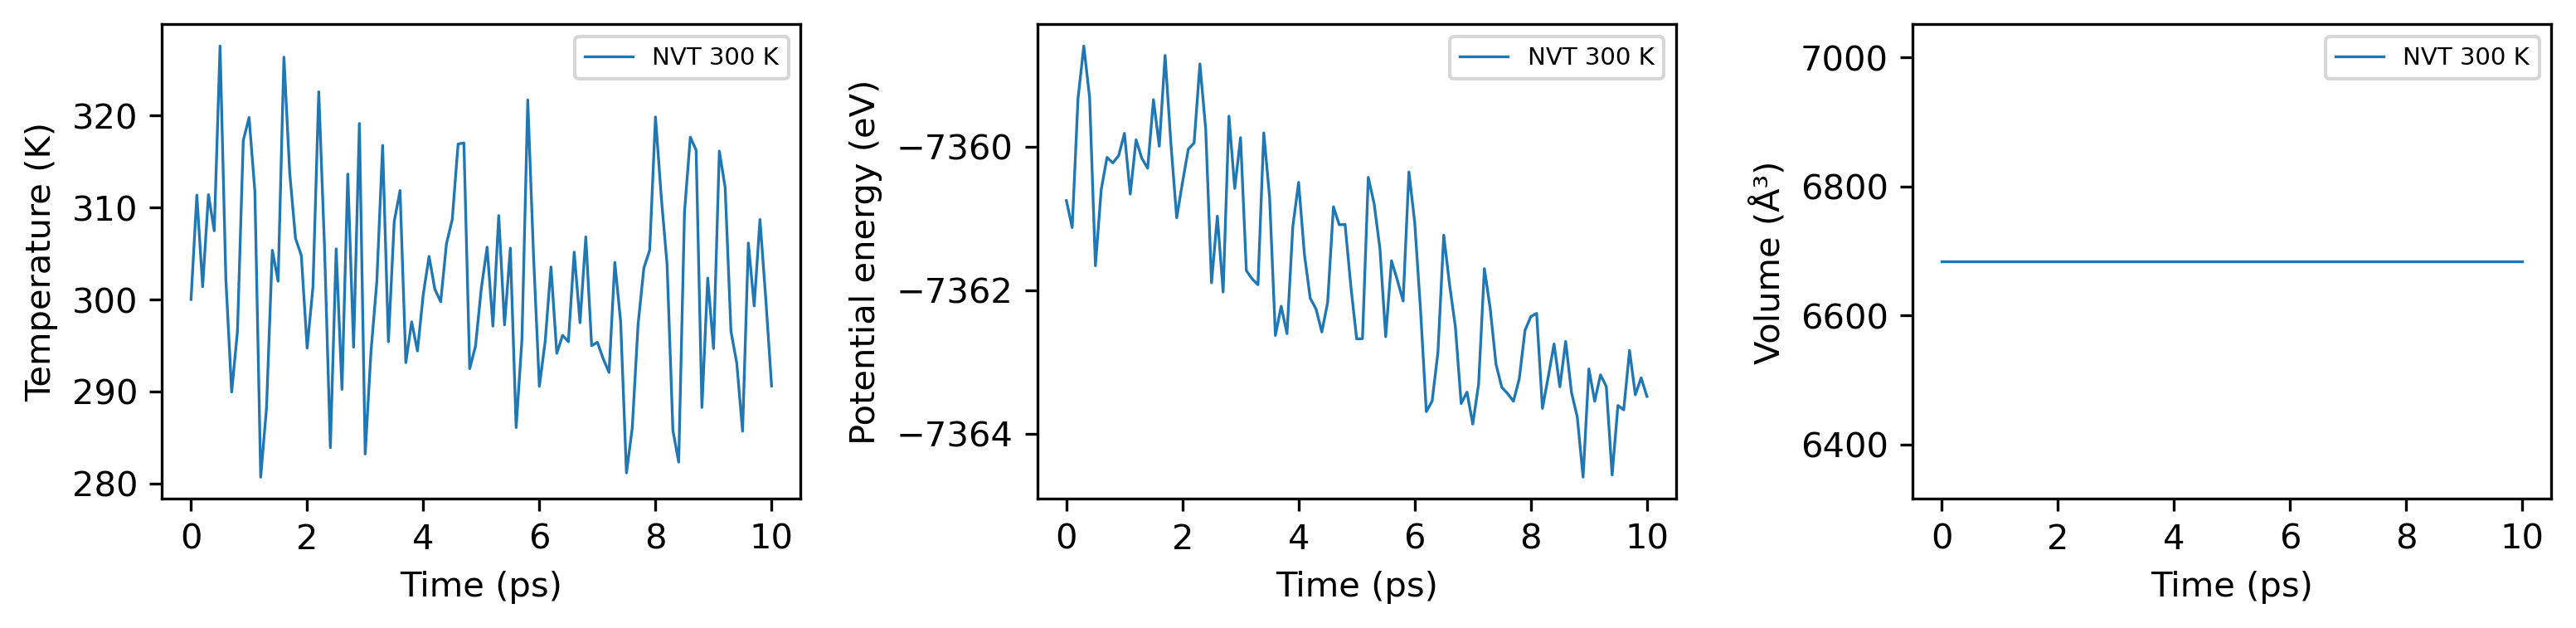

In [4]:
result_1 = am.md_simulation(
    structure=glass,
    potential=potential,
    temperature_sim=300.0,  # constant 300 K
    production_steps=10_000,  # 10 ps
    n_print=100,
    pressure=None,  # NVT — no pressure control
    seed=42,
)
glass_1 = result_1["structure"]
plot_schedule([result_1["result"]], labels=["NVT 300 K"])

## Example 2 — MD at Constant Temperature and Pressure (NPT)

Setting `pressure` to any float switches to NPT. The box volume is free to relax at the target pressure.

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


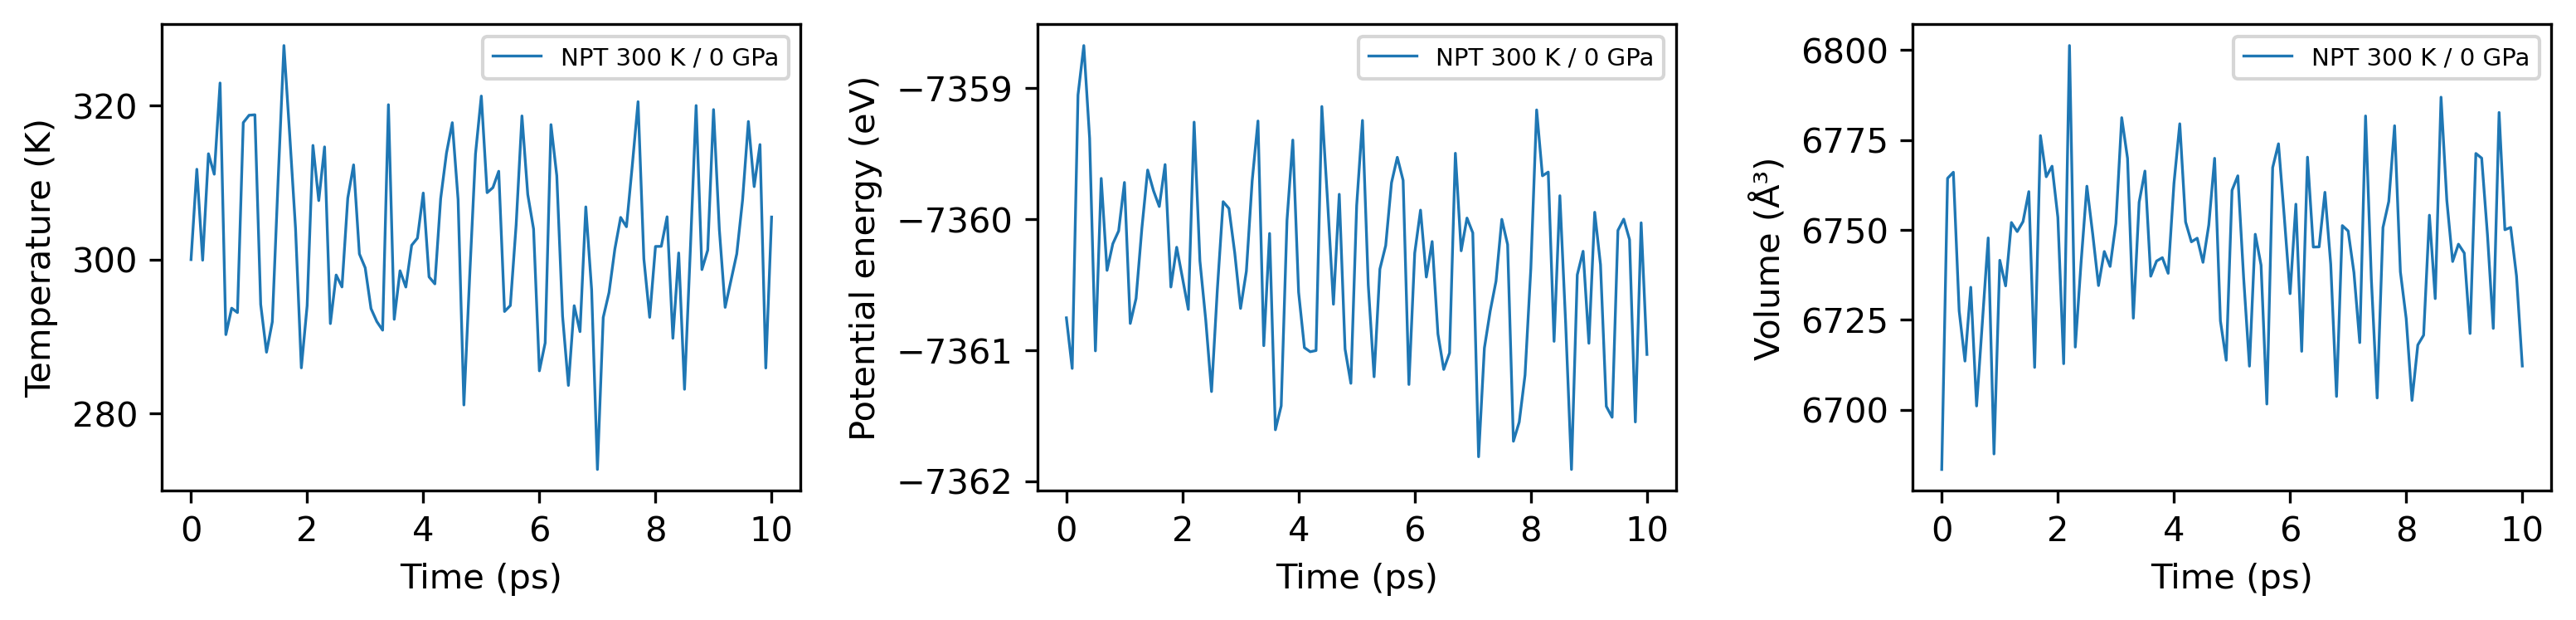

In [5]:
result_2 = am.md_simulation(
    structure=glass,
    potential=potential,
    temperature_sim=300.0,  # constant 300 K
    production_steps=10_000,  # 10 ps
    n_print=100,
    pressure=0.0,  # NPT at 0 GPa — box relaxes freely
    seed=42,
)
glass_2 = result_2["structure"]
plot_schedule([result_2["result"]], labels=["NPT 300 K / 0 GPa"])

## Example 3 — Temperature Ramp: Heating 300 → 4000 K at P = 0 GPa

`temperature_end` activates a linear temperature ramp within a single stage. LAMMPS ramps the thermostat target linearly from `temperature_sim` to `temperature_end` over `production_steps`.

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


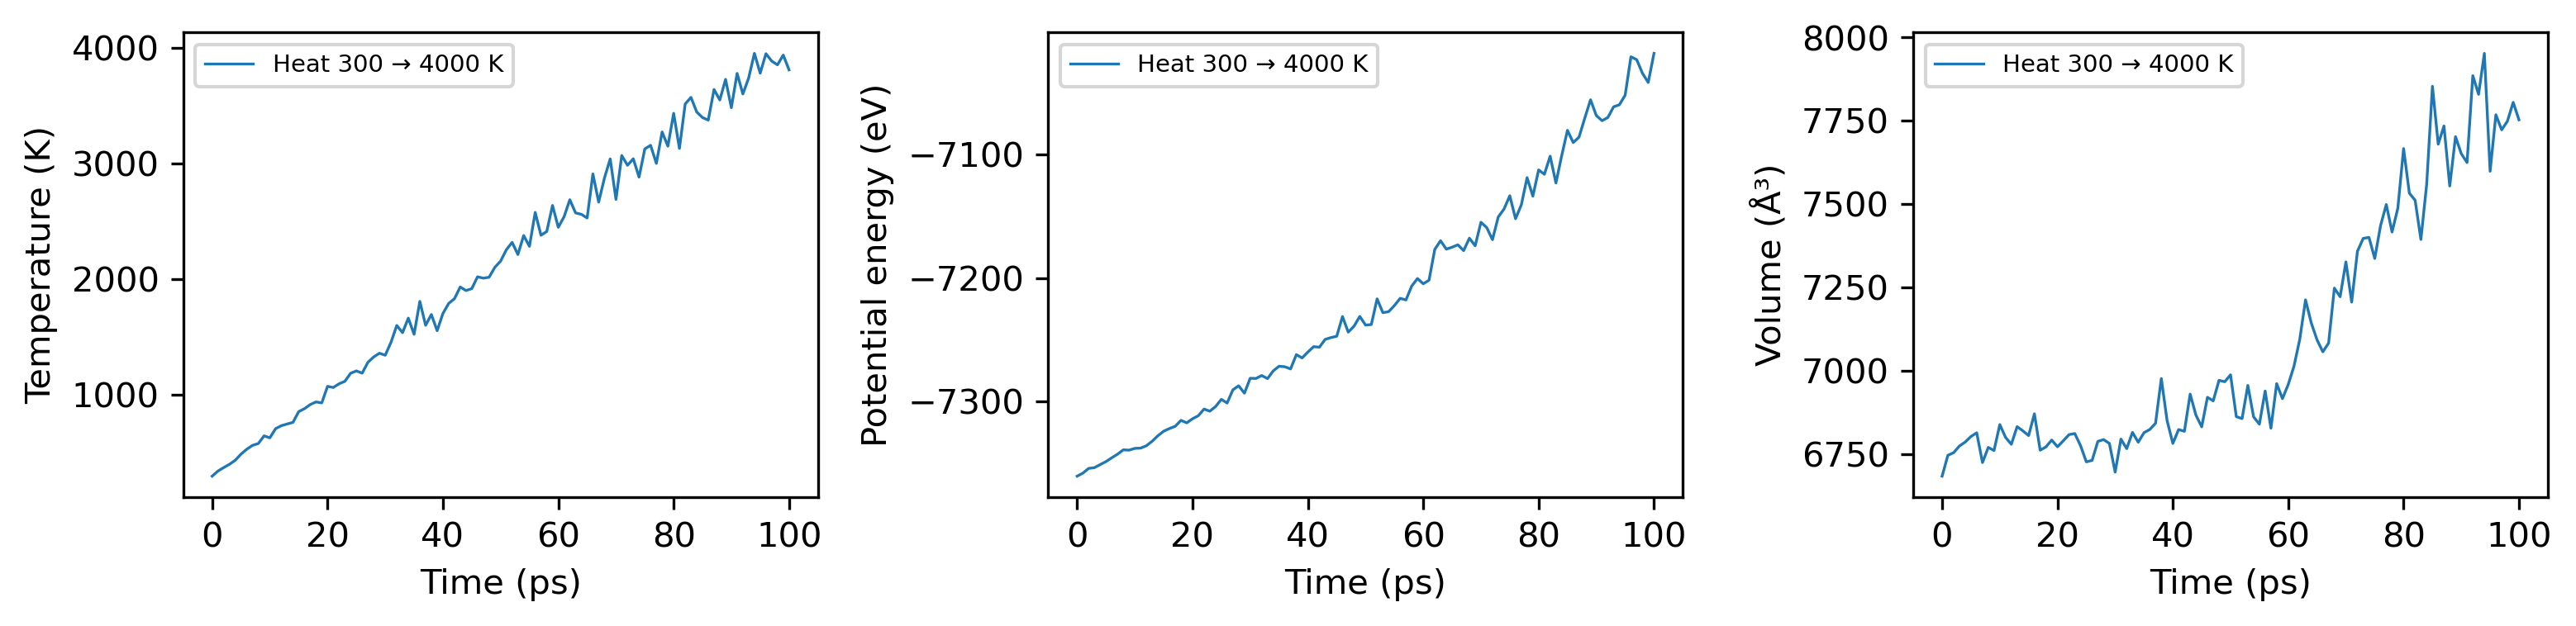

In [6]:
result_3 = am.md_simulation(
    structure=glass,
    potential=potential,
    temperature_sim=300.0,  # start temperature
    temperature_end=4000.0,  # end temperature — activates linear ramp
    production_steps=100_000,  # 100 ps
    n_print=1000,
    pressure=0.0,  # NPT at 0 GPa throughout
    seed=42,
)
glass_3 = result_3["structure"]
plot_schedule([result_3["result"]], labels=["Heat 300 → 4000 K"])

## Example 4 — Pressure Ramp: 300 K, P = 0 → 1 GPa

`pressure_end` activates a linear pressure ramp within a single stage. LAMMPS ramps the barostat target from `pressure` to `pressure_end`. Temperature stays constant.

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


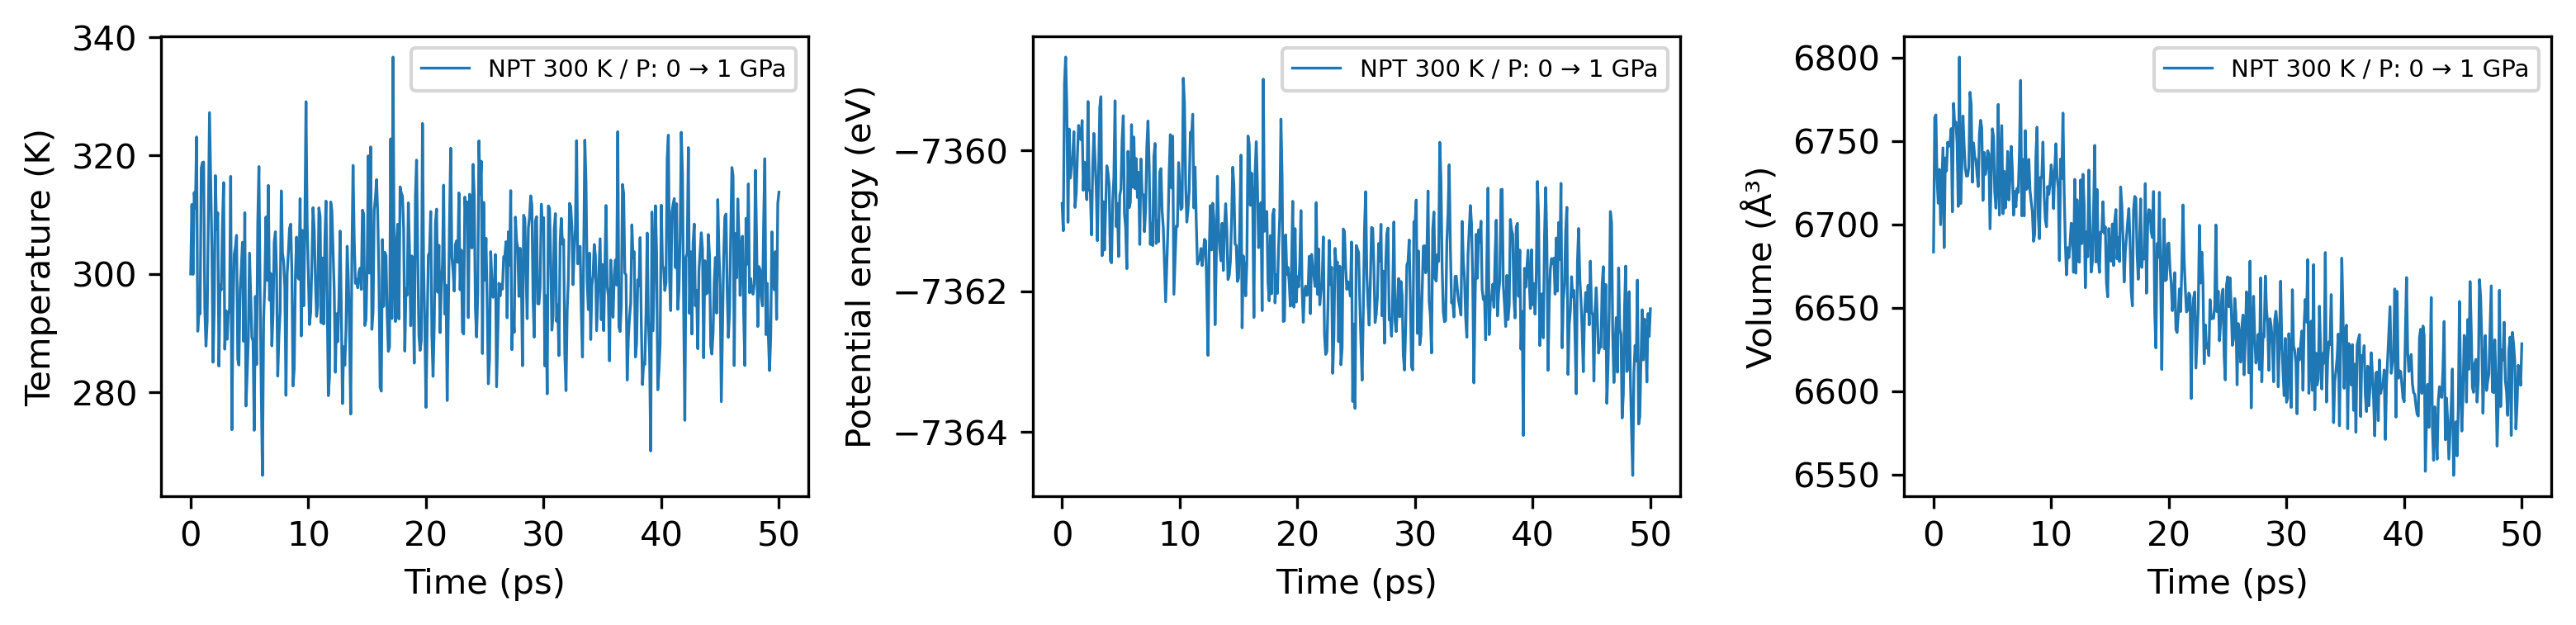

In [7]:
result_4 = am.md_simulation(
    structure=glass,
    potential=potential,
    temperature_sim=300.0,  # constant 300 K
    production_steps=50_000,  # 50 ps
    n_print=100,
    pressure=0.0,  # start pressure (GPa)
    pressure_end=1.0,  # end pressure — activates linear ramp
    seed=42,
)
glass_4 = result_4["structure"]
plot_schedule([result_4["result"]], labels=["NPT 300 K / P: 0 → 1 GPa"])

## Example 5 — Multi-Stage Schedule: Heat → Hold → Cool → Hold (P = 0 GPa)

Chain three `md_simulation` calls, passing the output structure of each stage as the input to the next. All stages run at P = 0 GPa (NPT).

- Stage 1: ramp 300 → 4000 K
- Stage 2: hold at 4000 K
- Stage 3: ramp 4000 → 300 K
- Stage 4: hold at 300 K

In [9]:
history_5 = []
labels_5 = []
current = glass

# Stage 1: heat 300 → 4000 K
res = am.md_simulation(
    structure=current,
    potential=potential,
    temperature_sim=300.0,
    temperature_end=4000.0,
    production_steps=50_000,  # 50 ps
    n_print=100,
    pressure=0.0,
    seed=42,
)
current = res["structure"]
history_5.append(res["result"])
labels_5.append("Heat 300 → 4000 K")

# Stage 2: hold at 4000 K
res = am.md_simulation(
    structure=current,
    potential=potential,
    temperature_sim=4000.0,
    production_steps=10_000,  # 10 ps
    n_print=100,
    pressure=0.0,
    seed=42,
)
current = res["structure"]
history_5.append(res["result"])
labels_5.append("Hold 4000 K")

# Stage 3: cool 4000 → 300 K
res = am.md_simulation(
    structure=current,
    potential=potential,
    temperature_sim=4000.0,
    temperature_end=300.0,
    production_steps=50_000,  # 50 ps
    n_print=100,
    pressure=0.0,
    seed=42,
)
current = res["structure"]
history_5.append(res["result"])
labels_5.append("Cool 4000 → 300 K")

# Stage 4: hold 300 K
res = am.md_simulation(
    structure=current,
    potential=potential,
    temperature_sim=300.0,
    production_steps=10_000,  # 10 ps
    n_print=100,
    pressure=0.0,
    seed=42,
)
current = res["structure"]
history_5.append(res["result"])
labels_5.append("Hold 300 K")

glass_5 = current
print("Final structure:", glass_5)

/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(
/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


Final structure: Atoms(symbols='Al76Ca39O307Si77', pbc=True, cell=[[18.931464090197565, 5.796089225308376e-15, 5.796089225308377e-15], [-4.636871380246702e-15, 18.931464090197565, 5.796089225308375e-15], [-4.636871380246699e-15, -4.636871380246702e-15, 18.931464090197565]], id=..., indices=..., initial_charges=..., masses=..., mmcharges=..., momenta=..., type=...)


/Users/achrafatila/miniforge3/envs/amorphouspy/lib/python3.13/site-packages/lammpsparser/units.py:242: UserWarning: Warning: Couldn't determine the LAMMPS to pyiron unit conversion type of quantity Density. Returning un-normalized quantity
  warnings.warn(


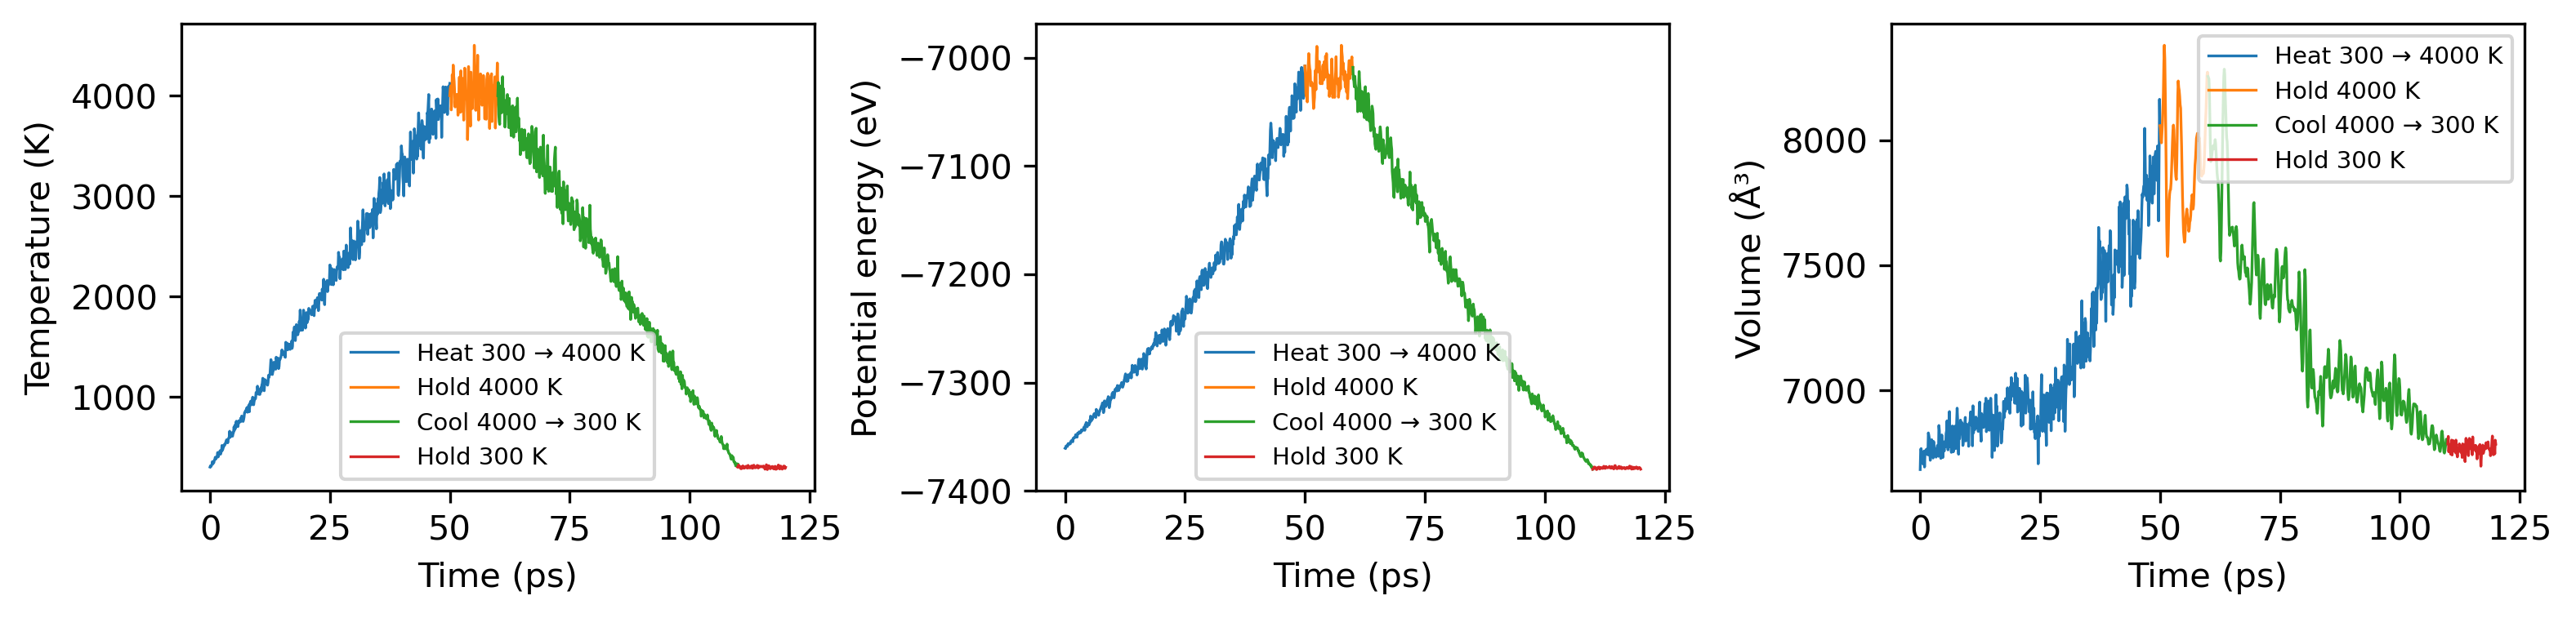

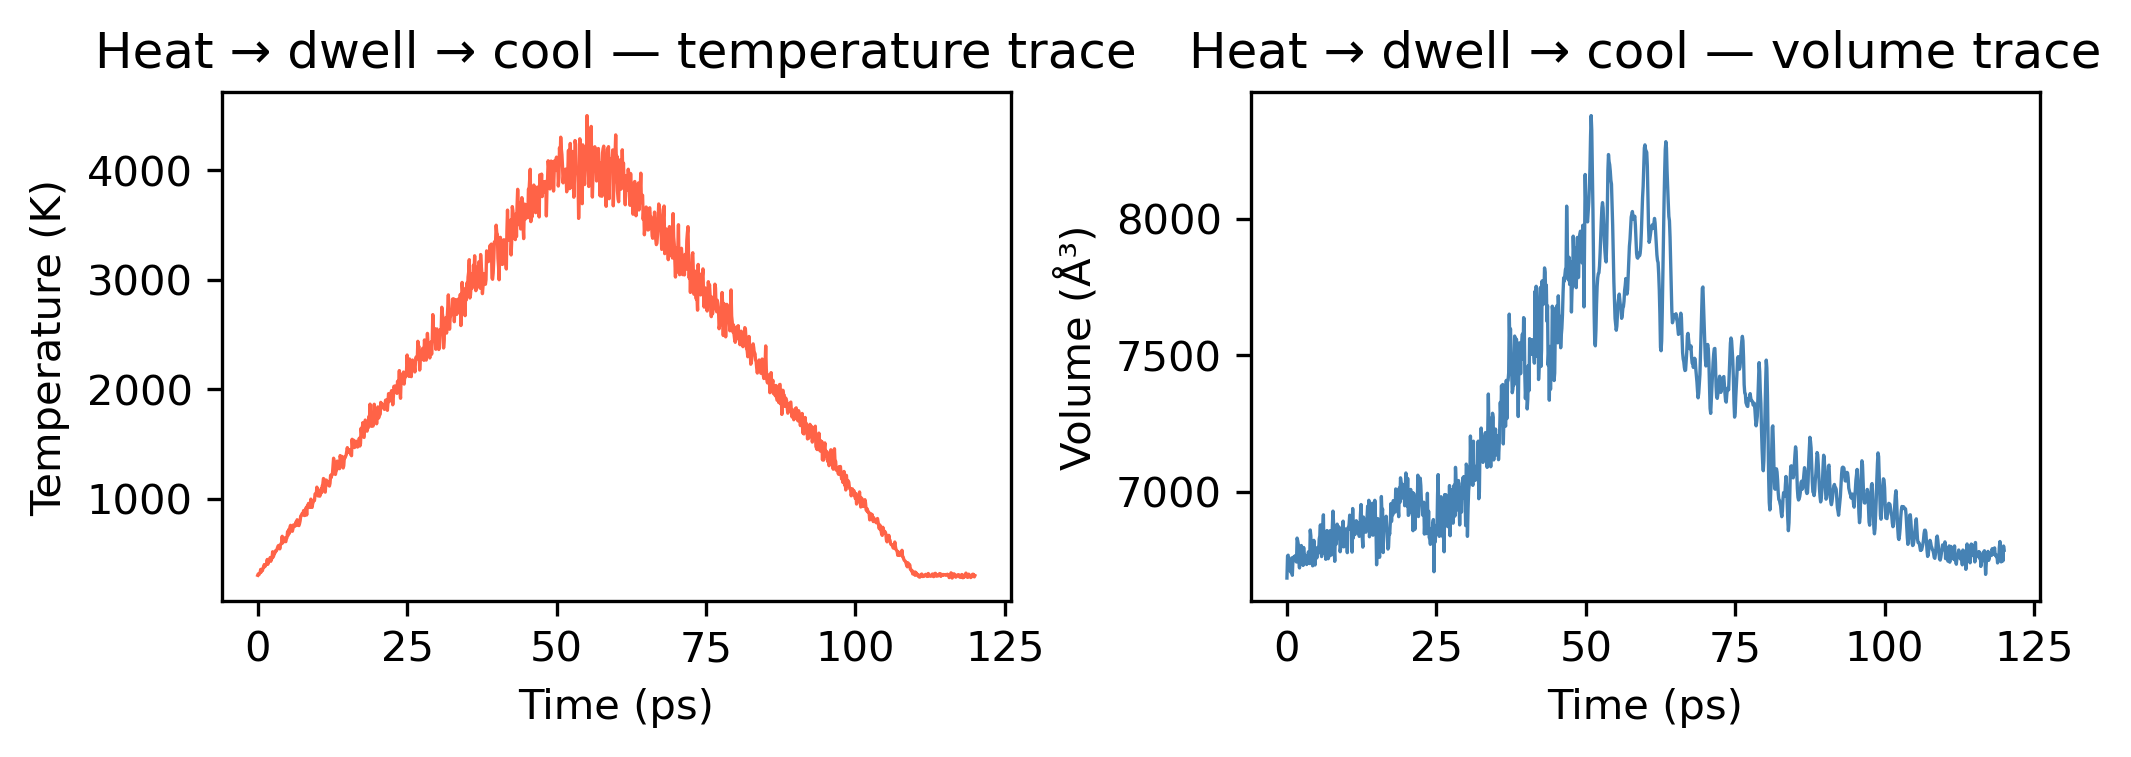

In [10]:
plot_schedule(history_5, labels=labels_5)

# Continuous trace using merge_thermo
merged = merge_thermo(history_5)
time_ps = merged["steps"] * 1e-3  # fs → ps (1 fs timestep)

_fig, axes = plt.subplots(1, 2, figsize=(3.5 * 2, 3.5 / 1.3333), dpi=300)
axes[0].plot(time_ps, merged["temperature"], lw=0.8, color="tomato")
axes[0].set_xlabel("Time (ps)")
axes[0].set_ylabel("Temperature (K)")
axes[0].set_title("Heat → dwell → cool — temperature trace")

axes[1].plot(time_ps, merged["volume"], lw=0.8, color="steelblue")
axes[1].set_xlabel("Time (ps)")
axes[1].set_ylabel("Volume (Å³)")
axes[1].set_title("Heat → dwell → cool — volume trace")

plt.tight_layout()
plt.show()

## Quick Reference

| Example | Key parameters | Ensemble |
|---------|----------------|----------|
| 1 — constant T | `temperature_sim=T, pressure=None` | NVT |
| 2 — constant T + P | `temperature_sim=T, pressure=P` | NPT |
| 3 — T ramp | `temperature_sim=T_start, temperature_end=T_end, pressure=0.0` | NPT |
| 4 — P ramp | `temperature_sim=T, pressure=P_start, pressure_end=P_end` | NPT |
| 5 — multi-stage | chain `result["structure"]` into next call | any |

Combined T + P ramp (both at once):
```python
am.md_simulation(...,
    temperature_sim=T_start, temperature_end=T_end,
    pressure=P_start, pressure_end=P_end,
)
```